In [ ]:
!pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.4/86.4 kB 4.6 MB/s eta 0:00:00


In [ ]:
# importamos todas las librerías necesarias para que aparezca correctament el gráfico

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
import numpy as np

from mplsoccer import FontManager

# Set pandas options to display all columns
pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/MIS_ANÁLISIS/Datos/datos_wyscout/MLPFD/Salida/s_Scout_TempActual_Jugadores.xlsx')


In [ ]:
#hacer copia para no perder el original
df_allplayers = df.drop('Unnamed: 0', axis=1)


In [ ]:
# Vemos los nombres de todas las columnas (estadísticas) que tiene la tabla de jugadores
# esto nos ayuda a saber qué datos podemos usar.

list(df_allplayers.columns)

['Jugador',
 'Equipo',
 'Equipo durante el período seleccionado',
 'Posición específica',
 'Edad',
 'Valor de mercado (Transfermarkt)',
 'Vencimiento contrato',
 'Partidos jugados',
 'Minutos jugados',
 'Goles',
 'xG',
 'Asistencias',
 'xA',
 'Duelos/90',
 'Duelos ganados %',
 'País de nacimiento',
 'Pasaporte',
 'Pie',
 'Altura',
 'Peso',
 'En prestamo',
 'Acciones defensivas realizadas/90',
 'Duelos defensivos/90',
 'Duelos defensivos ganados %',
 'Duelos aéreos/90',
 'Duelos aéreos ganados %',
 'Entradas/90',
 'Posesión conquistada después de una entrada',
 'Tiros interceptados/90',
 'Interceptaciones/90',
 'Posesión conquistada después de una interceptación',
 'Faltas/90',
 'Tarjetas amarillas',
 'Tarjetas amarillas/90',
 'Tarjetas rojas',
 'Tarjetas rojas/90',
 'Acciones de ataque exitosas/90',
 'Goles/90',
 'Goles (excepto los penaltis)',
 'Goles, excepto los penaltis/90',
 'xG/90',
 'Goles de cabeza',
 'Goles de cabeza/90',
 'Remates',
 'Remates/90',
 'Tiros a la portería %',
 '

In [ ]:
# de esta manera es como comprobamos que la lista de jugadores es la adecuada
# jugadores de la liga en la temporada 24/25
# el número 20 lo utilizamos para ver los 20 primeros jugadores que hay en la lista (va en orden alfabético)

df_allplayers.head(5)

,Jugador,Equipo,Equipo durante el período seleccionado,Posición específica,Edad,Valor de mercado (Transfermarkt),Vencimiento contrato,Partidos jugados,Minutos jugados,Goles,xG,Asistencias,xA,Duelos/90,Duelos ganados %,País de nacimiento,Pasaporte,Pie,Altura,Peso,En prestamo,Acciones defensivas realizadas/90,Duelos defensivos/90,Duelos defensivos ganados %,Duelos aéreos/90,Duelos aéreos ganados %,Entradas/90,Posesión conquistada después de una entrada,Tiros interceptados/90,Interceptaciones/90,Posesión conquistada después de una interceptación,Faltas/90,Tarjetas amarillas,Tarjetas amarillas/90,Tarjetas rojas,Tarjetas rojas/90,Acciones de ataque exitosas/90,Goles/90,Goles (excepto los penaltis),"Goles, excepto los penaltis/90",xG/90,Goles de cabeza,Goles de cabeza/90,Remates,Remates/90,Tiros a la portería %,Goles hechos %,Asistencias/90,Centros/90,Precisión centros %,Centros desde la banda izquierda/90,Precisión centros desde la banda izquierda %,Centros desde la banda derecha/90,Precisión centros desde la banda derecha %,Centros al área pequeña/90,Regates/90,Regates realizados %,Duelos atacantes/90,Duelos atacantes ganados %,Toques en el área de penalti/90,Carreras en progresión/90,Aceleraciones/90,Pases recibidos /90,Pases largos recibidos/90,Faltas recibidas/90,Pases/90,Precisión pases %,Pases hacia adelante/90,Precisión pases hacia adelante %,Pases hacia atrás/90,Precision pases hacia atrás %,Pases laterales/90,Precisión pases laterales %,Pases cortos / medios /90,Precisión pases cortos / medios %,Pases largos/90,Precisión pases largos %,"Longitud media pases, m","Longitud media pases largos, m",xA/90,Asistencias/90.1,Second assists/90,Third assists/90,Desmarques/90,Precisión desmarques %,Jugadas claves/90,Pases en el último tercio/90,Precisión pases en el último tercio %,Pases al área de penalti/90,Pases hacía el área pequeña %,Pases en profundidad/90,Precisión pases en profundidad %,Ataque en profundidad/90,Centros desde el último tercio/90,Pases progresivos/90,Precisión pases progresivos %,Goles recibidos,Goles recibidos/90,Remates en contra,Remates en contra/90,Porterías imbatidas/90,Paradas %,xG en contra,xG en contra/90,Goles evitados,Goles evitados/90,Pases hacía atrás recibidos del arquero/90,Salidas/90,Duelos aéreos/90.1,Tiros libres/90,Tiros libres directos/90,Tiros libres directos %,Córneres/90,Penaltis a favor,Penaltis realizados %,Competición,Temporada,Pais_Comp,Flag,Posición Principal,Fecha_Actualizacion
0,J. Bellingham,Real Madrid,Real Madrid,"AMF, LW, LCMF",21,180000000,2029-06-30,31,2713,9,12.19,4,2.94,19.84,47.66,England,England,derecho,186,75,no,7.13,5.11,59.74,2.59,39.74,1.19,1.82,0.03,2.89,4.39,1.09,5,0.17,1,0.03,3.09,0.30,8,0.27,0.40,2,0.07,61,2.02,37.70,14.754,0.13,0.93,32.14,0.56,35.29,0.30,11.11,0.17,3.09,56.99,9.39,46.29,3.25,2.29,0.53,42.06,1.06,2.02,48.77,88.57,12.54,79.63,9.69,96.58,17.02,90.64,45.38,91.01,2.52,64.47,17.36,38.60,0.10,1.00,0.00,0.00,0.66,40.00,0.53,6.10,80.98,2.75,46.99,1.13,26.47,1.39,0.30,4.54,85.40,0,NaN,0,NaN,0,0.0,0.0,0.0,NaN,NaN,0.33,NaN,NaN,0.00,0.00,0.00,0.03,2,50.000,1DIVI,2024-2025,ESP,https://images.fotmob.com/image_resources/logo...,Centrocampista,2025-06-27 14:39:39.859
1,K. Mbappé,Real Madrid,Real Madrid,CF,26,180000000,2029-06-30,34,3125,31,26.67,3,6.00,16.19,40.39,France,France,derecho,180,81,no,0.89,1.09,47.37,0.32,36.36,0.03,0.04,0.00,0.35,0.52,0.72,3,0.09,1,0.03,6.13,0.89,24,0.69,0.77,0,0.00,163,4.69,51.53,19.018,0.09,1.61,25.00,1.21,23.81,0.37,30.77,0.26,6.68,47.41,12.79,40.77,7.32,3.89,0.66,29.75,1.84,1.09,31.80,83.88,6.45,79.46,7.37,90.23,10.02,86.21,28.77,87.49,1.44,76.00,15.89,28.06,0.17,1.18,0.14,0.09,0.23,62.50,0.66,2.33,91.36,2.42,66.67,0.29,50.00,2.25,0.40,2.42,83.33,0,NaN,0,NaN,0,0.0,0.0,0.0,NaN,NaN,0.06,NaN,NaN,0.12,0.12,25.00,0.17,9,77.778,1DIVI,2024-2025,ESP,https://images.fotmob.com/image_resources/logo...,Delantero,2025-06-27 14:39:39.859
2,Vinícius Júnior,Real Madrid,Real Madrid,"CF, LAMF, LWF",24,180000000,2027-06-30,30,2415,11,13.20,8,7.45,22.2

In [ ]:
#FILTRAMOS EL DATASET SEGÚN NECESIDAD
# Filtro por temp. actual y similtud>0, Posicion y competicion
df_players = df_allplayers[(df_allplayers['Temporada'] == '2024-2025') &
                            (df_allplayers['Minutos jugados'] > 1000) &
                            (df_allplayers['Posición Principal'] == 'Delantero') &
                            (df_allplayers['Competición'] == '2RFEF') # | (df_similares['Competición'] == '3RFEF'))
                            ]

In [ ]:
#BUSCAR EL JUGADOR DESEADO
jugador_analizado = df_players[df_players['Jugador'].str.contains('Pachón')]
jugador = jugador_analizado['Jugador'].values[0]
print(jugador)

Álex Pachón


In [ ]:
jugador_analizado

,Jugador,Equipo,Equipo durante el período seleccionado,Posición específica,Edad,Valor de mercado (Transfermarkt),Vencimiento contrato,Partidos jugados,Minutos jugados,Goles,xG,Asistencias,xA,Duelos/90,Duelos ganados %,País de nacimiento,Pasaporte,Pie,Altura,Peso,En prestamo,Acciones defensivas realizadas/90,Duelos defensivos/90,Duelos defensivos ganados %,Duelos aéreos/90,Duelos aéreos ganados %,Entradas/90,Posesión conquistada después de una entrada,Tiros interceptados/90,Interceptaciones/90,Posesión conquistada después de una interceptación,Faltas/90,Tarjetas amarillas,Tarjetas amarillas/90,Tarjetas rojas,Tarjetas rojas/90,Acciones de ataque exitosas/90,Goles/90,Goles (excepto los penaltis),"Goles, excepto los penaltis/90",xG/90,Goles de cabeza,Goles de cabeza/90,Remates,Remates/90,Tiros a la portería %,Goles hechos %,Asistencias/90,Centros/90,Precisión centros %,Centros desde la banda izquierda/90,Precisión centros desde la banda izquierda %,Centros desde la banda derecha/90,Precisión centros desde la banda derecha %,Centros al área pequeña/90,Regates/90,Regates realizados %,Duelos atacantes/90,Duelos atacantes ganados %,Toques en el área de penalti/90,Carreras en progresión/90,Aceleraciones/90,Pases recibidos /90,Pases largos recibidos/90,Faltas recibidas/90,Pases/90,Precisión pases %,Pases hacia adelante/90,Precisión pases hacia adelante %,Pases hacia atrás/90,Precision pases hacia atrás %,Pases laterales/90,Precisión pases laterales %,Pases cortos / medios /90,Precisión pases cortos / medios %,Pases largos/90,Precisión pases largos %,"Longitud media pases, m","Longitud media pases largos, m",xA/90,Asistencias/90.1,Second assists/90,Third assists/90,Desmarques/90,Precisión desmarques %,Jugadas claves/90,Pases en el último tercio/90,Precisión pases en el último tercio %,Pases al área de penalti/90,Pases hacía el área pequeña %,Pases en profundidad/90,Precisión pases en profundidad %,Ataque en profundidad/90,Centros desde el último tercio/90,Pases progresivos/90,Precisión pases progresivos %,Goles recibidos,Goles recibidos/90,Remates en contra,Remates en contra/90,Porterías imbatidas/90,Paradas %,xG en contra,xG en contra/90,Goles evitados,Goles evitados/90,Pases hacía atrás recibidos del arquero/90,Salidas/90,Duelos aéreos/90.1,Tiros libres/90,Tiros libres directos/90,Tiros libres directos %,Córneres/90,Penaltis a favor,Penaltis realizados %,Competición,Temporada,Pais_Comp,Flag,Posición Principal,Fecha_Actualizacion
5242,Álex Pachón,Bergantiños,Bergantiños,CF,24,100000,2025-06-30,28,2332,10,8.33,2,0.87,27.86,34.35,Spain,Spain,derecho,185,80,no,2.62,2.35,60.66,8.18,43.4,0.0,0.0,0.04,1.2,1.67,1.31,1,0.04,0,0.0,2.62,0.39,10,0.39,0.32,0,0.0,59,2.28,45.76,16.949,0.08,0.81,33.33,0.15,25.0,0.66,35.29,0.15,2.59,49.25,11.89,27.27,3.32,0.69,0.27,10.96,1.81,1.47,17.33,74.39,3.05,58.23,6.17,88.13,4.48,68.97,15.78,77.51,0.77,50.0,14.8,20.62,0.03,0.42,0.0,0.0,0.04,100.0,0.35,1.35,62.86,0.73,52.63,0.0,0.0,0.62,0.31,1.16,56.67,0,NaN,0,NaN,0,0.0,0.0,0.0,NaN,NaN,0.04,NaN,NaN,0.0,0.0,0.0,0.0,0,0.0,2RFEF,2024-2025,ESP,https://images.fotmob.com/image_resources/logo...,Delantero,2025-06-27 14:39:39.859


In [ ]:
# Mostramos la lista completa de columnas del DataFrame
# así vemos qué estadísticas de los jugadores tenemos disponibles para escoger en el análisis
print(df_players.columns.tolist())

['Jugador', 'Equipo', 'Equipo durante el período seleccionado', 'Posición específica', 'Edad', 'Valor de mercado (Transfermarkt)', 'Vencimiento contrato', 'Partidos jugados', 'Minutos jugados', 'Goles', 'xG', 'Asistencias', 'xA', 'Duelos/90', 'Duelos ganados %', 'País de nacimiento', 'Pasaporte', 'Pie', 'Altura', 'Peso', 'En prestamo', 'Acciones defensivas realizadas/90', 'Duelos defensivos/90', 'Duelos defensivos ganados %', 'Duelos aéreos/90', 'Duelos aéreos ganados %', 'Entradas/90', 'Posesión conquistada después de una entrada', 'Tiros interceptados/90', 'Interceptaciones/90', 'Posesión conquistada después de una interceptación', 'Faltas/90', 'Tarjetas amarillas', 'Tarjetas amarillas/90', 'Tarjetas rojas', 'Tarjetas rojas/90', 'Acciones de ataque exitosas/90', 'Goles/90', 'Goles (excepto los penaltis)', 'Goles, excepto los penaltis/90', 'xG/90', 'Goles de cabeza', 'Goles de cabeza/90', 'Remates', 'Remates/90', 'Tiros a la portería %', 'Goles hechos %', 'Asistencias/90', 'Centros/90

In [ ]:
fase_defensiva = ['Acciones defensivas realizadas/90','Duelos aéreos/90',
                'Duelos aéreos ganados %','Duelos defensivos ganados %','Duelos defensivos/90','Entradas/90',
                'Faltas/90','Interceptaciones/90','Posesión conquistada después de una entrada',
                'Posesión conquistada después de una interceptación','Tarjetas amarillas','Tarjetas amarillas/90',
                'Tarjetas rojas','Tarjetas rojas/90','Tiros interceptados/90']
abp = ['Córneres/90','Penaltis a favor','Penaltis realizados %','Tiros libres directos %',
       'Tiros libres directos/90','Tiros libres/90']
acc_ofensivas = ['Acciones de ataque exitosas/90','Aceleraciones/90','Asistencias','Asistencias/90',
                'Carreras en progresión/90','Centros al área pequeña/90','Centros desde la banda derecha/90',
                'Centros desde la banda izquierda/90','Centros/90','Duelos atacantes ganados %',
                'Duelos atacantes/90','Faltas recibidas/90','Goles','Goles (excepto los penaltis)',
                'Goles de cabeza','Goles de cabeza/90','Goles hechos %','Goles, excepto los penaltis/90',
                'Goles/90','Pases largos recibidos/90','Pases recibidos /90','Precisión centros %',
                'Precisión centros desde la banda derecha %','Precisión centros desde la banda izquierda %',
                'Regates realizados %','Regates/90','Remates','Remates/90','Tiros a la portería %',
                'Toques en el área de penalti/90','xG','xG/90']
fisica = ['Total Distance per 90','Running Distance per 90 (15-20 km/h)','HSR Distance per 90 (20-25 km/h)',
          'Sprinting Distance per 90 (+25 km/h)','HI Distance per 90 (+20 km/h)','Meter/Min','Max Speed (km/h)',
          'Count Medium Acceleration per 90 (1.5 m/s² to 3 m/s²)','Count High Acceleration per 90 (+3 m/s²)',
          'Count Medium Deceleration per 90 (-1.5 m/s² to -3 m/s²)','Count High Deceleration per 90 (-3 m/s²)',
          'Count HSR per 90 (20-25 km/h)','Count Sprint per 90 (+25 km/h)','Count HI per 90 (+20 km/h)']
jugadas_clave = ['Asistencias','Asistencias/90',
                'Ataque en profundidad/90','Centros desde el último tercio/90','Desmarques/90',
                'Jugadas claves/90','Pases al área de penalti/90','Pases en el último tercio/90',
                'Pases en profundidad/90','Pases hacía el área pequeña %','Pases progresivos/90',
                'Precisión desmarques %','Precisión pases en el último tercio %',
                'Precisión pases en profundidad %','Precisión pases progresivos %','Second assists/90',
                'Third assists/90','xA','xA/90']
organizacion = ['Longitud media pases largos, m','Longitud media pases, m','Pases cortos / medios /90',
                'Pases hacia adelante/90','Pases hacia atrás/90','Pases largos/90','Pases laterales/90',
                'Pases/90','Precisión pases %','Precisión pases cortos / medios %',
                'Precisión pases hacia adelante %','Precision pases hacia atrás %','Precisión pases largos %',
                'Precisión pases laterales %']
portero = ['Acciones defensivas realizadas/90','Duelos aéreos/90',
          'Duelos aéreos ganados %','Duelos defensivos ganados %','Duelos ganados %','Goles evitados',
          'Goles evitados/90','Goles recibidos','Goles recibidos/90','Longitud media pases largos, m',
          'Longitud media pases, m','Paradas %','Pases hacia adelante/90',
          'Pases hacía atrás recibidos del arquero/90','Pases hacia atrás/90','Pases largos/90',
          'Pases laterales/90','Pases/90','Porterías imbatidas en los 90','Precisión pases %',
          'Precisión pases cortos / medios %','Precisión pases hacia adelante %',
          'Precision pases hacia atrás %','Precisión pases largos %','Precisión pases laterales %',
          'Remates en contra','Remates en contra/90','Salidas/90','xG en contra','xG en contra/90']

Finalización = ['Goles', 'Goles (excepto los penaltis)', 'Goles de cabeza', 'Goles de cabeza/90',
                'Goles hechos %', 'Goles, excepto los penaltis/90', 'Goles/90', 'Remates', 'Remates/90',
                'Tiros a la portería %', 'xG/90'
                ]


In [ ]:
# Elegimos una serie de estadísticas que son especialmente relevantes para evaluar a delanteros.
# Estas métricas incluyen aspectos de finalización, participación en ataque y generación de jugadas.
# 'stats_plot' contiene los nombres técnicos (columnas del DataFrame) que vamos a analizar.
# 'stats_labels' contiene cómo se mostrará -qué nombre veremos- cada métrica en los gráficos.
# eres libre de cambiar a las que quieras siempre que uses los nombres de la celda anterior

stats_plot = {
    "Delanteros": ['Goles/90',
               'Toques en el área de penalti/90',
               'Remates/90',
               'Duelos atacantes/90',
               'Tiros a la portería %',
               'xG/90'
            ]
          }
stats_labels = {
    "Delanteros": ['Goles/90',
               'Toques en el área de penalti/90',
               'Remates/90',
               'Duelos atacantes/90',
               'Tiros a la portería %',
               'xG/90'
            ]
          }

In [ ]:
# Este código convierte la columna "stats_90s" (minutos jugados divididos por 90) a valores numéricos
# es importante para eliminar a aquellos jugadores que han participado poco en el filtro de la próxima celda

df_players['Minutos jugados'].astype(float).sort_values()

,Minutos jugados
159,1048.0
495,1071.0
169,1176.0
107,1184.0
207,1198.0
88,1221.0
550,1233.0
307,1239.0
34,1244.0
223,1245.0


In [ ]:
stats_plot

{'Delanteros': ['Goles/90',
  'Toques en el área de penalti/90',
  'Remates/90',
  'Duelos atacantes/90',
  'Tiros a la portería %',
  'xG/90']}

In [ ]:
stats_labels

{'Delanteros': ['Goles/90',
  'Toques en el área de penalti/90',
  'Remates/90',
  'Duelos atacantes/90',
  'Tiros a la portería %',
  'xG/90']}

/tmp/ipython-input-1702211654.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  edad = int(player['Edad'])


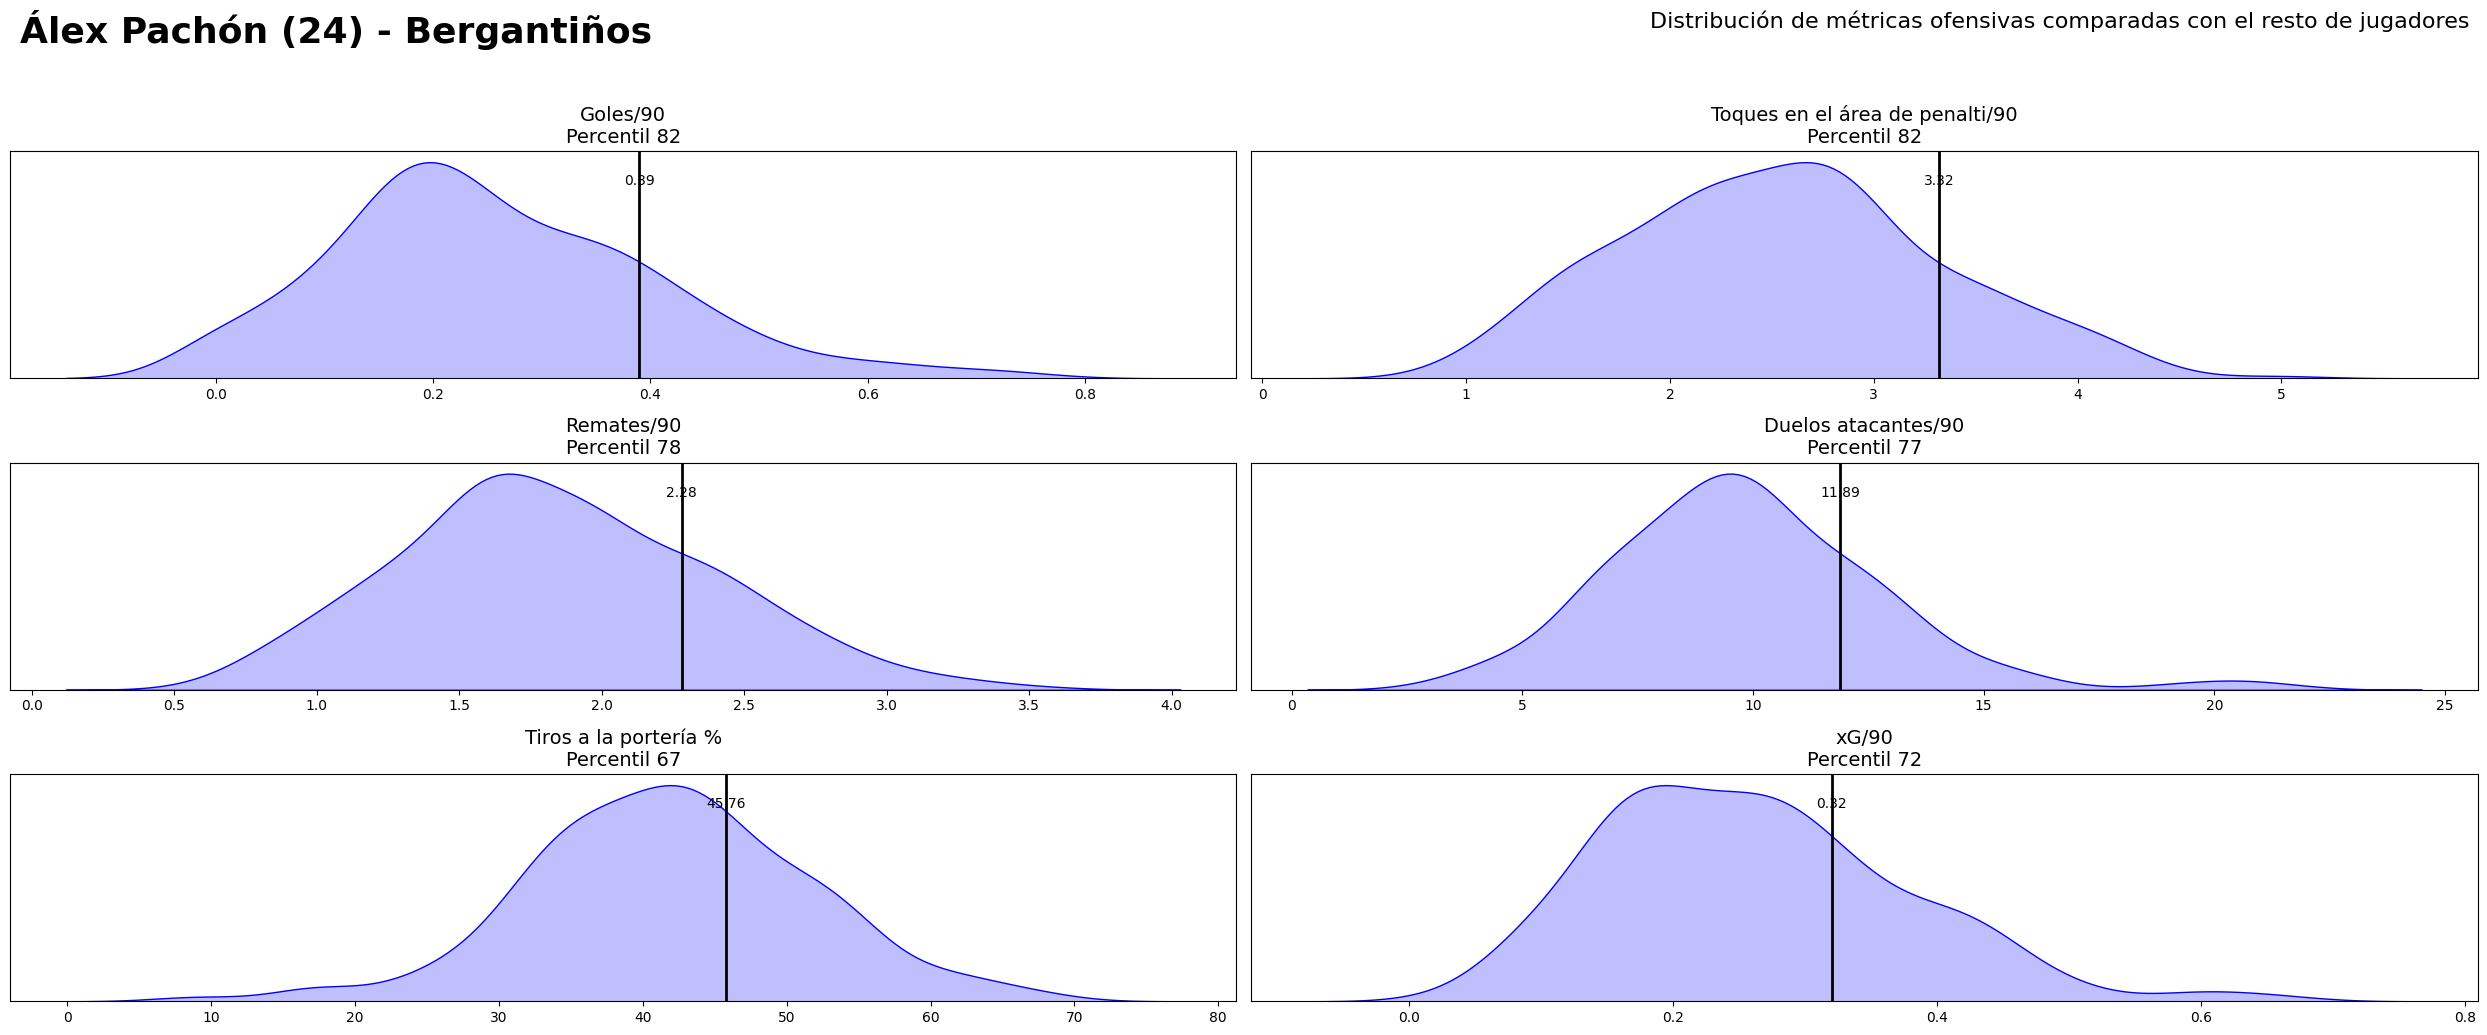

In [ ]:
# Estas librerías también tienen que ser instaladas para que el gráfico aparezca bien tras todo lo anterior

from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ▸ Parámetros del jugador
player = df_players[df_players['Jugador'] == jugador]

# mensaje que nos dará el gráfico si ese jugador no está dentro del filtro
if player.empty:
    raise ValueError(f"El jugador {jugador} no fue encontrado en el DataFrame.")

# Obtenemos el equipo y la edad del jugador seleccionado:

equipo = player['Equipo durante el período seleccionado'].values[0]
edad = int(player['Edad'])

# Preparación del gráfico en cuanto a tamaño
#OJO, AQUI CAMBIAMOS SEGÚN NUMERO DE METRICAS A MOSTRAR ******************************
fig, axes = plt.subplots(3, 2, figsize=(25, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)
col = 'blue' #aquí puedes cambiar el color por el que quieras

# Convertimos la columna correspondiente a valores numéricos y eliminamos valores vacíos (NaN).

for i, ax in zip(range(len(stats_plot["Delanteros"])), axes.reshape(-1)):
    stat = df_players[stats_plot["Delanteros"][i]].astype(float).dropna()
    stat.name = None

    try:
        player_value = float(player[stats_plot["Delanteros"][i]].values[0])
        percentile = stats.percentileofscore(stat, player_value)
    except:
        player_value = None
        percentile = None

    sns.kdeplot(stat, ax=ax, color=col, fill=True, legend=False)

    if player_value is not None:
        ax.axvline(player_value, color='black', linewidth=2)
        ax.text(player_value, ax.get_ylim()[1]*0.9, f'{player_value:.2f}',
                color='black', ha='center', va='top', fontsize=10)

        xmin, xmax = ax.get_xlim()
        if player_value < xmin or player_value > xmax:
            ax.set_xlim(min(xmin, player_value - 1), max(xmax, player_value + 1))

    titulo = f"{stats_labels['Delanteros'][i]}"
    if percentile is not None:
        titulo += f"\nPercentil {int(percentile)}"
    ax.set_title(titulo, fontsize=14)

    ax.set(xlabel=None)
    ax.set(ylabel=None)
    ax.set(yticks=[])

# Esto agrega el título al gráfico (jugador + edad + equipo)

fig.text(0.01, 1.03, f'{jugador} ({edad}) - {equipo}',
         fontsize=26, fontweight='bold', ha='left', va='top')

# ▸ SUBTÍTULO A LA DERECHA
fig.text(0.99, 1.03,
         'Distribución de métricas ofensivas comparadas con el resto de jugadores',
         fontsize=16, ha='right', va='top')

# ▸ Layout con margen superior
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f'{jugador.replace(" ", "_")}_perfil_ofensivo.png', dpi=300, bbox_inches='tight')
plt.show()